Модель нейронов места.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats.qmc import Sobol, PoissonDisk
# for normal distribution pdf
from scipy.stats import norm

# from scipy.spatial import Voronoi

# for plotting circles
from matplotlib.collections import PatchCollection

from sklearn.metrics import pairwise_distances

In [2]:
from model import PlaceCellsModel

In [3]:
from ripser import Rips

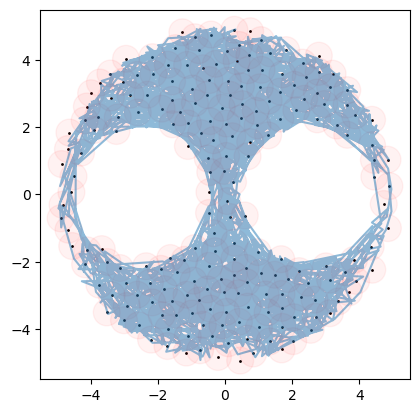

In [4]:
m = PlaceCellsModel(n_holes=2, move_time_frac=0.99, n_cells=1024, cell_radius=0.04, sigma_activation=1.)

geo = m.geometry

traj = m.sample_Levy_walk(n_steps=2_000, min_step=0.3, max_step=5., exponent=1.5)

points = m.cells

fig, ax = plt.subplots()

_ = ax.scatter(points[:,0], points[:,1], c='black', s=1.)

circles = [plt.Circle((xi, yi), radius=0.04*10, fill=True, alpha=0.05, color='red') for xi, yi in points]

collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)

offset = 0.5

_ = ax.set(aspect='equal', 
           xlim=[-5-offset, 5+offset], ylim=[-5-offset, 5+offset])
          #,xlabel=r'$x_1$', ylabel=r'$x_2$',)

_ = ax.plot(traj[:,0], traj[:,1], alpha=0.5)

plt.show()

In [5]:
m.n_cells

205

Text(0, 0.5, 'time')

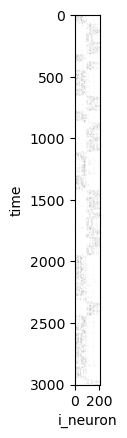

In [20]:
s = m.sample_signal(n_steps=3_000)

plt.imshow(1-s, cmap='gray')

plt.xlabel('i_neuron')
plt.ylabel('time')

In [21]:
s += np.random.normal(size=s.shape, loc=0, scale=0.01)

From scipy.spatial.distance: `[‘braycurtis’, ‘canberra’, ‘chebyshev’, ‘correlation’, ‘dice’, ‘hamming’, ‘jaccard’, ‘kulsinski’, ‘mahalanobis’, ‘minkowski’, ‘rogerstanimoto’, ‘russellrao’, ‘seuclidean’, ‘sokalmichener’, ‘sokalsneath’, ‘sqeuclidean’, ‘yule’]`

$d(u,v)=$

`‘braycurtis’`: $\sum{|u_i-v_i|}/\sum{|u_i+v_i|}$ - более-менее

`‘canberra’`: $\sum_i \frac{|u_i-v_i|}{|u_i|+|v_i|}$ - на практике очень плохо, т.к. не вариативно

`‘chebyshev’`: $\max_{1 \le i \le n} |u_i-v_i|$ - ясно что будет очень плохо

`‘correlation’`: $1 - \frac{(u - \bar{u}) \cdot (v - \bar{v})}
                  {{\|(u - \bar{u})\|}_2 {\|(v - \bar{v})\|}_2}$ - **очень неплохо**!
                  
`‘dice’` - только между булевыми, не пойдет

`‘hamming’` - только между дискретными

`‘jaccard’` - только между дискретными

`‘mahalanobis’`: $\sqrt{ (u-v) V^{-1} (u-v)^T },$ где $V$ - матрица ковариации. плохо, очень долго считать

`‘minkowski’`: ${\|u-v\|}_p = (\sum{|u_i - v_i|^p})^{1/p}$ - со стандартными $p=1,2$ плохо различает

`‘rogerstanimoto’` - только между булевыми

`russellrao’` - только между булевыми

`‘seuclidean’` - $\sqrt{\sum\limits_i \frac{1}{V_i} \left(u_i-v_i \right)^2}$, где $V$ – вектор дисперсий. примерно то же что Минковский получается

`sokalmichener` - только между булевыми

`‘sokalsneath’` - только между булевыми

`‘sqeuclidean’` - квадрат Евклида, то есть Минковский

`‘yule’` – только булевы

**TLDR: берем correlation**

In [22]:
d = pairwise_distances(s, s, 'correlation')

#d = 1-d

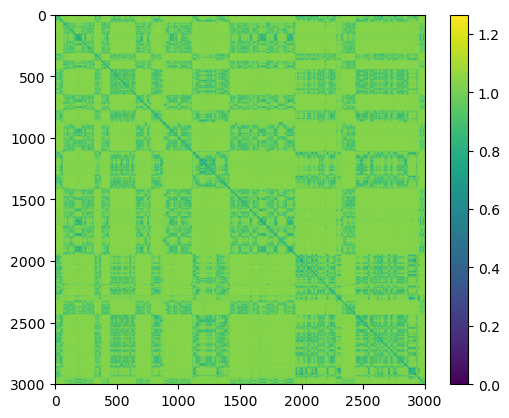

In [23]:
plt.imshow(d)
plt.colorbar()

In [24]:
d.shape

(3001, 3001)

In [25]:
rips = Rips()

#diagrams = rips.fit_transform(s)

diagrams = rips.fit_transform(d, distance_matrix=True)

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


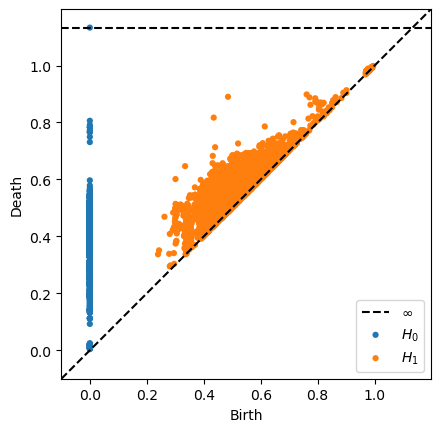

In [26]:
rips.plot(diagrams)